# Dow Jones Industrial Average — Component Analysis

An exploratory data analysis (EDA) of the 30 companies in the Dow Jones
Industrial Average (DJIA), built with pandas. The notebook follows a typical
analyst workflow: pulling reference data directly from a live public source,
assessing data quality, slicing and filtering, aggregating by group, and
summarizing results with simple visualizations.

**Data source**

This notebook reads the "Components" table directly from Wikipedia's
[Dow Jones Industrial Average](https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average)
article, which is published under the
[Creative Commons Attribution-ShareAlike 4.0 License](https://creativecommons.org/licenses/by-sa/4.0/).
No local data files are required — if a live connection is available, the
notebook fetches the current table; otherwise it falls back to a small cached
snapshot (`dow_components_snapshot.csv`, retrieved June 2026) so the analysis
remains fully reproducible offline.

**Output**

- `dow_jones_components_clean.csv` — the cleaned, analysis-ready dataset
  generated at the end of this notebook

## 1. Setup

In [ ]:
import io
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

WIKI_URL = "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"
SNAPSHOT_PATH = "dow_components_snapshot.csv"
HEADERS = {"User-Agent": "dow-jones-component-analysis/1.0 (educational notebook)"}

## 2. Fetching the Data

The cell below tries to read the "Components" table directly from Wikipedia.
A custom `User-Agent` header is sent because Wikipedia blocks the default
Python user agent. If the request fails for any reason — no internet
connection, a network policy, a temporary outage — the notebook falls back
to a cached snapshot of the same table so the rest of the analysis still
runs.

In [ ]:
try:
    response = requests.get(WIKI_URL, headers=HEADERS, timeout=10)
    response.raise_for_status()
    tables = pd.read_html(io.StringIO(response.text))
    raw = next(
        t for t in tables
        if {"Symbol", "Sector", "Index weighting"}.issubset(set(t.columns))
    )
    source = "live Wikipedia fetch"
except Exception as exc:
    raw = pd.read_csv(SNAPSHOT_PATH)
    source = f"cached snapshot (live fetch unavailable: {exc!r})"

print(f"Loaded {len(raw)} components from {source}.")
raw.head()

Loaded 30 components from cached snapshot (live fetch unavailable: HTTPError('403 Client Error: Forbidden for url: https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average')).


,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.97%
1,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.98%
2,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.70%
3,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.80%
4,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,3.36%


## 3. Cleaning the Data

Two adjustments make the raw table easier to work with:

- `Index weighting` is stored as text (e.g., `"3.98%"`). Converting it to a
  numeric column enables sorting, aggregation, and plotting.
- `Symbol` uniquely identifies each company, so it becomes the DataFrame
  index — enabling direct lookups like `dow_components.loc["AAPL"]`.

In [ ]:
dow_components = raw.copy()
dow_components["Index Weight (%)"] = (
    dow_components["Index weighting"].str.rstrip("%").astype(float)
)
dow_components = dow_components.set_index("Symbol")
dow_components.head()

,Company,Exchange,Sector,Date added,Notes,Index weighting,Index Weight (%)
Symbol,,,,,,,
MMM,3M,NYSE,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.97%,1.97
AXP,American Express,NYSE,Financials,1982-08-30,NaN,3.98%,3.98
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,NaN,4.70%,4.70
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,NaN,2.80%,2.80
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,NaN,3.36%,3.36


## 4. Data Quality Check

In [ ]:
print(f"{dow_components.shape[0]} components across {dow_components.shape[1]} attributes\n")
dow_components.info()

30 components across 7 attributes

<class 'pandas.DataFrame'>
Index: 30 entries, MMM to WMT
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           30 non-null     str    
 1   Exchange          30 non-null     str    
 2   Sector            30 non-null     str    
 3   Date added        30 non-null     str    
 4   Notes             5 non-null      str    
 5   Index weighting   30 non-null     str    
 6   Index Weight (%)  30 non-null     float64
dtypes: float64(1), str(6)
memory usage: 1.9+ KB


In [ ]:
missing = dow_components.isna().sum().rename("missing_values").to_frame()
missing["pct_missing"] = (missing["missing_values"] / len(dow_components) * 100).round(1)
missing

,missing_values,pct_missing
Company,0,0.0
Exchange,0,0.0
Sector,0,0.0
Date added,0,0.0
Notes,25,83.3
Index weighting,0,0.0
Index Weight (%),0,0.0


The only column with missing values is `Notes`, which is expected — it is
only populated for companies with a more complex listing history (e.g.,
re-added to the index after a prior removal, or a name change).

## 5. Exploring the Dataset

In [ ]:
dow_components.head(10)

,Company,Exchange,Sector,Date added,Notes,Index weighting,Index Weight (%)
Symbol,,,,,,,
MMM,3M,NYSE,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.97%,1.97
AXP,American Express,NYSE,Financials,1982-08-30,NaN,3.98%,3.98
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,NaN,4.70%,4.70
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,NaN,2.80%,2.80
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,NaN,3.36%,3.36
BA,Boeing,NYSE,Industrials,1987-03-12,NaN,2.64%,2.64
CAT,Caterpillar,NYSE,Industrials,1991-05-06,NaN,9.46%,9.46
CVX,Chevron,NYSE,Energy,2008-02-19,Also 1930-07-18 to 1999-11-01,2.76%,2.76
CSCO,Cisco,NASDAQ,Information Technology,2009-06-08,NaN,1.08%,1.08


In [ ]:
dow_components.tail(10)

,Company,Exchange,Sector,Date added,Notes,Index weighting,Index Weight (%)
Symbol,,,,,,,
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,NaN,0.70%,0.70
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,NaN,2.36%,2.36
PG,Procter & Gamble,NYSE,Consumer Staples,1932-05-26,NaN,1.92%,1.92
CRM,Salesforce,NYSE,Information Technology,2020-08-31,NaN,2.41%,2.41
SHW,Sherwin-Williams,NYSE,Materials,2024-11-08,NaN,4.22%,4.22
TRV,"Travelers Companies, Inc.",NYSE,Financials,2009-06-08,NaN,3.87%,3.87
UNH,UnitedHealth Group,NYSE,Health Care,2012-09-24,NaN,3.59%,3.59
VZ,Verizon,NYSE,Communication Services,2004-04-08,NaN,0.67%,0.67
V,Visa,NYSE,Financials,2013-09-23,NaN,4.05%,4.05


## 6. Targeted Lookups

Business questions are often about a single entity. With `Symbol` as the
index, looking up a specific company is a single `.loc[]` call.

In [ ]:
dow_components.loc[["AAPL"]]

,Company,Exchange,Sector,Date added,Notes,Index weighting,Index Weight (%)
Symbol,,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,NaN,3.36%,3.36


In [ ]:
apple_exchange = dow_components.loc["AAPL", "Exchange"]
print(f"Apple Inc. (AAPL) trades on the {apple_exchange}.")

Apple Inc. (AAPL) trades on the NASDAQ.


## 7. Sector Composition

Grouping by `Sector` shows how diversified the index is across the economy.

In [ ]:
sector_counts = dow_components["Sector"].value_counts()
sector_counts

,count
Sector,
Information Technology,6
Financials,5
Industrials,4
Health Care,4
Consumer Discretionary,4
Consumer Staples,3
Communication Services,2
Energy,1
Materials,1


In [ ]:
dow_components.sort_values(["Sector", "Company"])

,Company,Exchange,Sector,Date added,Notes,Index weighting,Index Weight (%)
Symbol,,,,,,,
DIS,Disney,NYSE,Communication Services,1991-05-06,NaN,1.28%,1.28
VZ,Verizon,NYSE,Communication Services,2004-04-08,NaN,0.67%,0.67
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,NaN,2.80%,2.80
HD,Home Depot,NYSE,Consumer Discretionary,1999-11-01,NaN,4.41%,4.41
MCD,McDonald's,NYSE,Consumer Discretionary,1985-10-30,NaN,4.14%,4.14
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,NaN,0.70%,0.70
KO,Coca-Cola,NYSE,Consumer Staples,1987-03-12,Also 1932-05-26 to 1935-11-20,1.00%,1.00
PG,Procter & Gamble,NYSE,Consumer Staples,1932-05-26,NaN,1.92%,1.92
WMT,Walmart,NASDAQ,Consumer Staples,1997-03-17,NaN,1.64%,1.64


## 8. Filtering by Sector

When filtering text fields from an external source, comparing on a
lowercased copy of the column is a cheap habit that protects against
inconsistent capitalization if the source formatting ever changes.

In [ ]:
tech_components = dow_components[
    dow_components["Sector"].str.lower() == "information technology"
]
tech_components[["Company", "Exchange", "Index Weight (%)"]]

,Company,Exchange,Index Weight (%)
Symbol,,,
AAPL,Apple,NASDAQ,3.36
CSCO,Cisco,NASDAQ,1.08
IBM,IBM,NYSE,3.21
MSFT,Microsoft,NASDAQ,4.93
NVDA,Nvidia,NASDAQ,2.36
CRM,Salesforce,NYSE,2.41


## 9. Identifying Legacy Components

The `Notes` column flags companies with a more complex listing history.

In [ ]:
legacy_components = dow_components[dow_components["Notes"].notna()]
legacy_components[["Company", "Date added", "Notes"]]

,Company,Date added,Notes
Symbol,,,
MMM,3M,1976-08-09,As Minnesota Mining and Manufacturing
CVX,Chevron,2008-02-19,Also 1930-07-18 to 1999-11-01
KO,Coca-Cola,1987-03-12,Also 1932-05-26 to 1935-11-20
HON,Honeywell,2020-08-31,AlliedSignal and Honeywell
IBM,IBM,1979-06-29,Also 1932-05-26 to 1939-03-04


## 10. A Simplified Reference View

For dashboards or downstream reporting, a leaner view without free-text
notes is often preferable.

In [ ]:
dow_components_summary = dow_components.drop(columns=["Notes", "Index weighting"])
dow_components_summary.head()

,Company,Exchange,Sector,Date added,Index Weight (%)
Symbol,,,,,
MMM,3M,NYSE,Industrials,1976-08-09,1.97
AXP,American Express,NYSE,Financials,1982-08-30,3.98
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,4.70
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,2.80
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.36


## 11. Index Weighting Analysis

Because the DJIA is price-weighted, a handful of high-priced stocks can
dominate the index regardless of company size. Sorting by `Index Weight (%)`
surfaces those components directly.

In [ ]:
top_weighted = dow_components.sort_values("Index Weight (%)", ascending=False)
top_weighted[["Company", "Sector", "Index Weight (%)"]].head(10)

,Company,Sector,Index Weight (%)
Symbol,,,
GS,Goldman Sachs,Financials,11.10
CAT,Caterpillar,Industrials,9.46
MSFT,Microsoft,Information Technology,4.93
AMGN,Amgen,Health Care,4.70
HD,Home Depot,Consumer Discretionary,4.41
SHW,Sherwin-Williams,Materials,4.22
MCD,McDonald's,Consumer Discretionary,4.14
V,Visa,Financials,4.05
AXP,American Express,Financials,3.98


## 12. Sector-Level Aggregation

Grouping by `Sector` and aggregating shows not just how many companies fall
into each sector, but how much combined influence each sector has on the
index.

In [ ]:
sector_summary = (
    dow_components.groupby("Sector")["Index Weight (%)"]
    .agg(num_components="count", total_weight="sum", avg_weight="mean")
    .sort_values("total_weight", ascending=False)
    .round(2)
)
sector_summary

,num_components,total_weight,avg_weight
Sector,,,
Financials,5,26.91,5.38
Information Technology,6,17.35,2.89
Industrials,4,17.09,4.27
Health Care,4,13.09,3.27
Consumer Discretionary,4,12.05,3.01
Consumer Staples,3,4.56,1.52
Materials,1,4.22,4.22
Energy,1,2.76,2.76
Communication Services,2,1.95,0.98


## 13. Visualizing the Results

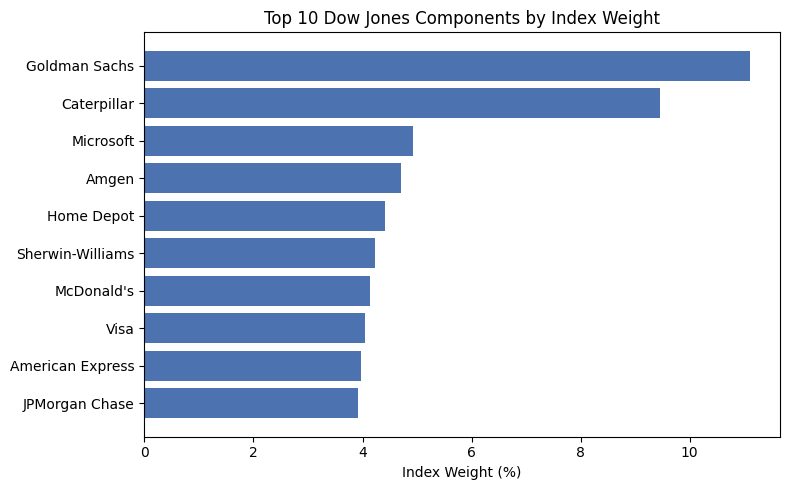

In [ ]:
top_10 = top_weighted.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_10["Company"], top_10["Index Weight (%)"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Index Weight (%)")
ax.set_title("Top 10 Dow Jones Components by Index Weight")
fig.tight_layout()
plt.show()

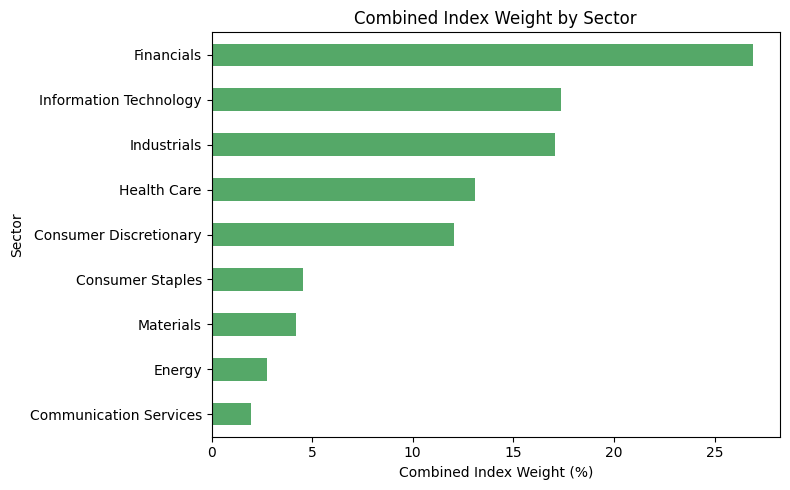

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sector_summary["total_weight"].sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Combined Index Weight (%)")
ax.set_title("Combined Index Weight by Sector")
fig.tight_layout()
plt.show()

## 14. Exporting the Results

In [ ]:
output_path = "dow_jones_components_clean.csv"
dow_components.to_csv(output_path)
print(f"Cleaned dataset written to {output_path}")

Cleaned dataset written to dow_jones_components_clean.csv


## Key Takeaways

- **Financials** carry the largest combined index weight (26.91%), driven
  largely by **Goldman Sachs** (11.10%) — the single largest component —
  along with Visa, JPMorgan Chase, American Express, and Travelers.
- **Information Technology** is the most *numerous* sector (6 of 30
  components), but its combined weight (17.35%) is slightly below
  Industrials (17.09%), which has only 4 components — a direct illustration
  of how price weighting decouples "share count" from "influence."
- **Caterpillar** (9.46%) is the second-largest single component, despite
  Industrials being a smaller sector by company count than Information
  Technology or Financials.
- Only 5 of the 30 components carry historical notes about prior index
  membership or name changes, indicating the dataset is largely complete and
  consistent.

*Note: figures reflect the data available at the time this notebook was run
(live fetch or cached snapshot) and will update automatically on the next run
if a live connection is available.*